# Figure 3 — Bayesian observer model parameters in MS and control groups

Reproduces the three model-parameter panels of Figure 3:

* **A** measurement noise $w_m$
* **B** motor noise $w_r$
* **C** multiplicative gain factor $\alpha$

Each panel is a beeswarm of the per-subject maximum-likelihood fits with a horizontal group-mean bar; groups are compared with the test selected by the paper's normality rule (Shapiro-Wilk -> t-test / Mann-Whitney U).

**Input:** `results/subject_params.csv` (generate with `python scripts/fit_all_subjects.py`).

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / "mstiming").exists() else _root.parent
sys.path.insert(0, str(_root))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mstiming import config, data_io, fitting, plotting, stats
plotting.setup_style()

if not config.SUBJECT_PARAMS_CSV.exists():
    raise FileNotFoundError(
        "Missing results/subject_params.csv -- run: python scripts/fit_all_subjects.py")
params = pd.read_csv(config.SUBJECT_PARAMS_CSV)
print("subjects per group:", params.groupby("group").size().to_dict())
params.head()

subjects per group: {'Control': 140, 'MS': 79}


,ID,group_code,group,w_m,w_r,alpha,nll,slope,intercept,n_trials
0,550234195,CN,Control,0.302707,0.224490,0.892103,-19.334045,0.621354,0.339070,218
1,1080554841,CN,Control,0.283116,0.138983,1.050869,-55.580690,0.695613,0.386372,232
2,1741795796,CN,Control,0.152125,0.191004,1.112476,-33.037910,0.882321,0.222015,231
3,1272462439,CN,Control,0.511310,0.350451,1.181327,144.627376,0.180579,1.051840,227
4,1940762596,CN,Control,0.231534,0.131675,1.044594,-80.449851,0.884696,0.189652,219


## Group comparison statistics
Parameter mapping: `w_m` = measurement noise, `w_r` = motor noise (the code's production noise `w_p`), `alpha` = gain factor.

In [2]:

specs = [("w_m", r"$w_m$ (measurement noise)", (0.05, 0.85), [0.1, 0.45, 0.8]),
         ("w_r", r"$w_r$ (motor noise)",       (0.05, 0.85), [0.1, 0.45, 0.8]),
         ("alpha", r"$\alpha$ (gain factor)", (0.30, 2.05), [0.4, 1.2, 2.0])]

pvals = {}
rows = []
for col, _, _, _ in specs:
    cn = params.loc[params.group == "Control", col].values
    ms = params.loc[params.group == "MS", col].values
    res = stats.compare_two_groups(cn, ms)
    pvals[col] = res["p"]
    rows.append({"param": col, "Control (mean+/-sd)": f"{res['a']['mean']:.2f} +/- {res['a']['sd']:.2f}",
                 "MS (mean+/-sd)": f"{res['b']['mean']:.2f} +/- {res['b']['sd']:.2f}",
                 "test": res["test"], "stat": round(res["stat"], 1),
                 "p": round(res["p"], 3), "cohen_d": round(stats.cohens_d(ms, cn), 2)})
pd.DataFrame(rows)

,param,Control (mean+/-sd),MS (mean+/-sd),test,stat,p,cohen_d
0,w_m,0.32 +/- 0.11,0.38 +/- 0.15,Mann-Whitney U,4328.0,0.008,0.44
1,w_r,0.24 +/- 0.09,0.23 +/- 0.10,Mann-Whitney U,5713.0,0.685,-0.01
2,alpha,0.98 +/- 0.20,0.96 +/- 0.26,Mann-Whitney U,5414.0,0.798,-0.07


## Figure

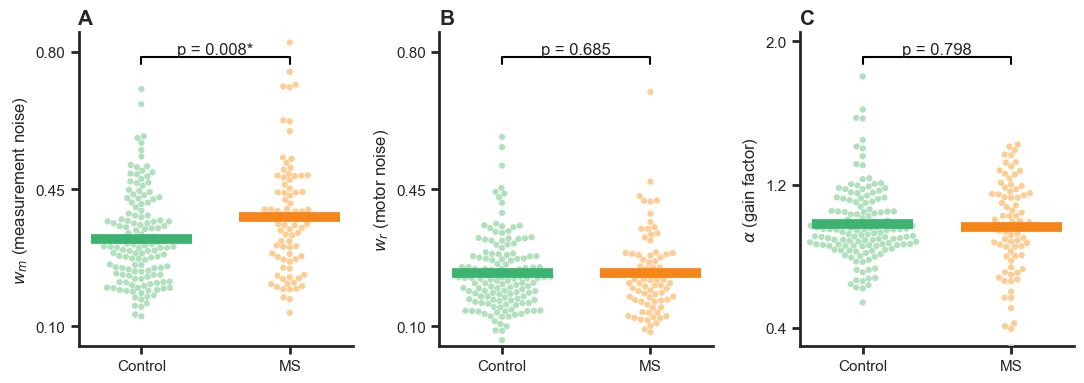

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, (col, label, ylim, yticks) in zip(axes, specs):
    plotting.beeswarm_mean(ax, params, col, order=["Control", "MS"],
                           ylabel=label, ylim=ylim, yticks=yticks, pval=pvals[col])
for ax, letter in zip(axes, "ABC"):
    ax.set_title(letter, loc="left", fontweight="bold", fontsize=15)
fig.tight_layout()
config.FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIG_DIR / "Figure3.pdf", bbox_inches="tight")
fig.savefig(config.FIG_DIR / "Figure3.png", dpi=300, bbox_inches="tight")
plt.show()